In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df= pd.read_csv('bank+marketing/bank-additional/bank-additional/bank-additional-full.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Performing EDA

In [4]:
## Checking for missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [5]:
## Total missing value in the dataset
df.isnull().sum().sum()

np.int64(0)

In [6]:
## show only columns with missing values
missing= df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [7]:
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [8]:
## checking the % of unknown
unk_pct= ((df == 'unknown').sum() /len(df)) * 100
print(unk_pct[unk_pct>0].sort_values(ascending=False))

default      20.872584
education     4.202680
housing       2.403613
loan          2.403613
job           0.801204
marital       0.194231
dtype: float64


In [9]:
df["education"].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [10]:
df["default"].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [11]:
## checking whether the "unknown" impact the target
pd.crosstab(df['education'], df['y'], normalize='index') * 100

y,no,yes
education,,
basic.4y,89.750958,10.249042
basic.6y,91.797557,8.202443
basic.9y,92.175352,7.824648
high.school,89.164477,10.835523
illiterate,77.777778,22.222222
professional.course,88.651535,11.348465
university.degree,86.275477,13.724523
unknown,85.499711,14.500289


In [12]:
pd.crosstab(df['default'], df['y'], normalize='index') * 100

y,no,yes
default,,
no,87.121026,12.878974
unknown,94.847040,5.152960
yes,100.000000,0.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [14]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [15]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [16]:
## columns containing unknown
for col in df.columns:
    if(df[col] == 'unknown').any():
        print(col, (df[col] == 'unknown').sum())

job 330
marital 80
education 1731
default 8597
housing 990
loan 990


In [17]:
## Checking the target distribution
df['y'].value_counts()
df['y'].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

<Axes: xlabel='y', ylabel='count'>

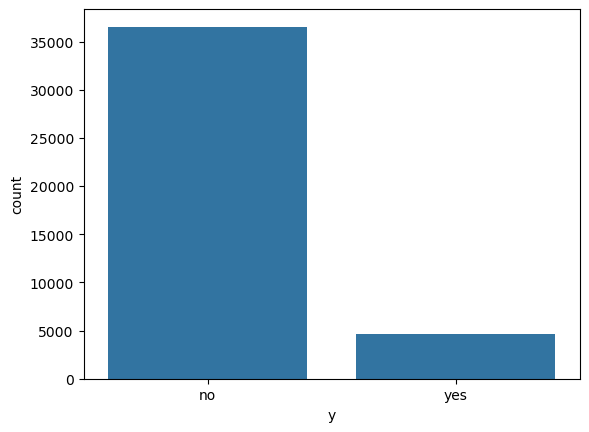

In [18]:
## visualize
sns.countplot(x='y', data=df)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>,
        <Axes: title={'center': 'emp.var.rate'}>],
       [<Axes: title={'center': 'cons.price.idx'}>,
        <Axes: title={'center': 'cons.conf.idx'}>,
        <Axes: title={'center': 'euribor3m'}>],
       [<Axes: title={'center': 'nr.employed'}>, <Axes: >, <Axes: >]],
      dtype=object)

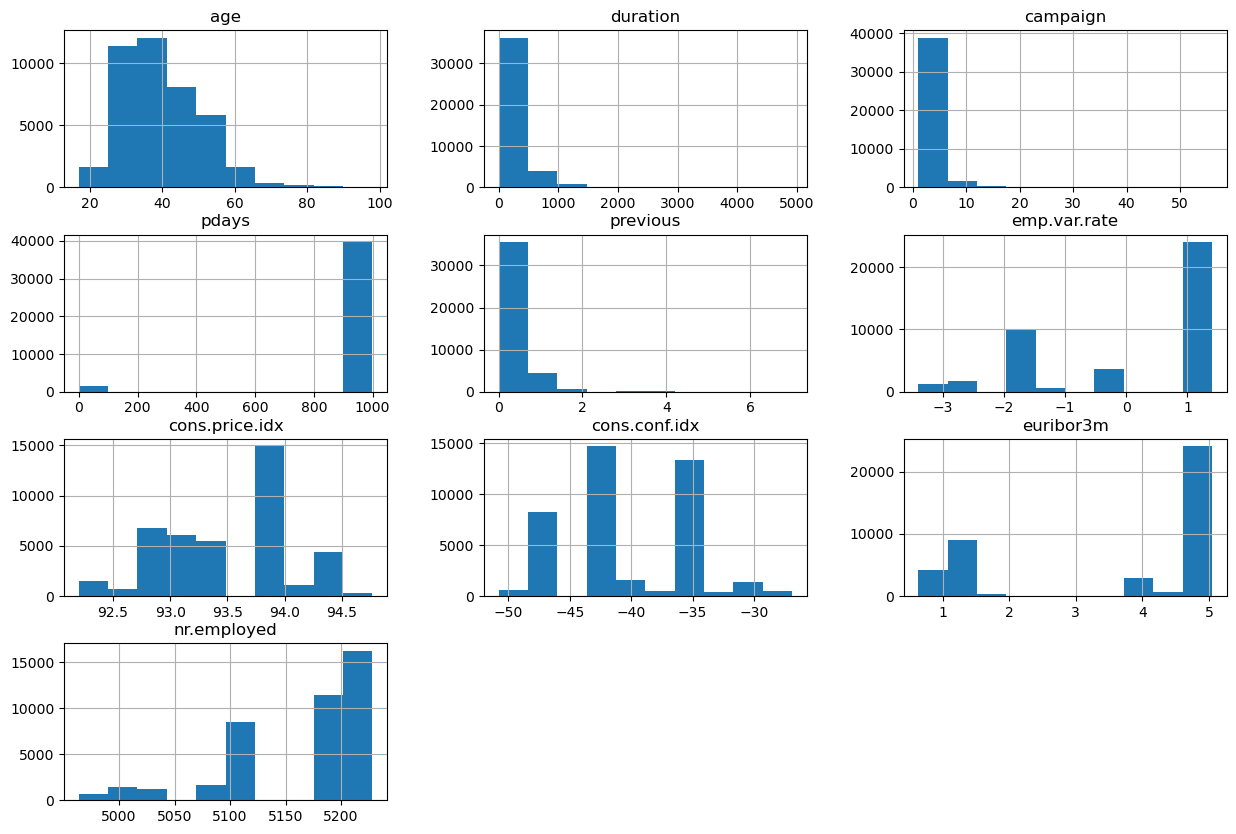

In [19]:
## numerical variable analysis
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(figsize=(15,10))

In [20]:
df[num_cols].skew()

age               0.784697
duration          3.263141
campaign          4.762507
pdays            -4.922190
previous          3.832042
emp.var.rate     -0.724096
cons.price.idx   -0.230888
cons.conf.idx     0.303180
euribor3m        -0.709188
nr.employed      -1.044262
dtype: float64

<Axes: xlabel='age'>

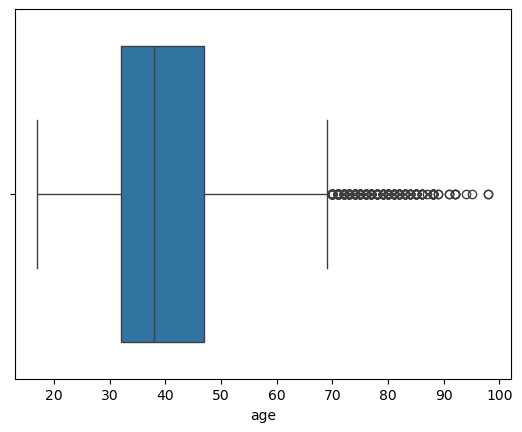

In [21]:
## plot boxplot
sns.boxplot(x=df['age'])

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
contact
cellular     26144
telephone    15044
Name: count, dtype: in

<Axes: xlabel='count', ylabel='job'>

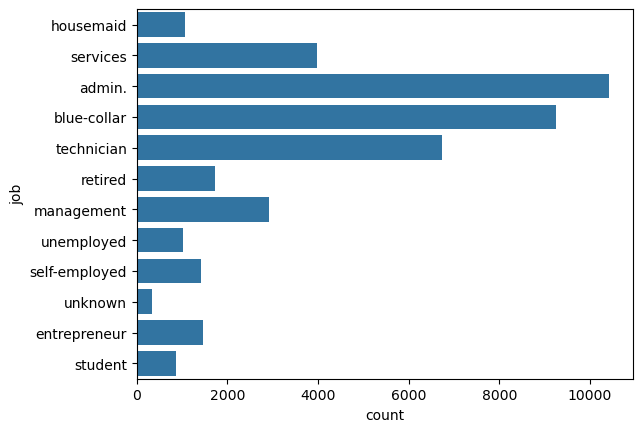

In [22]:
## categorical varaiable analysis
cat_cols = df.select_dtypes(include= 'object').columns
for col in cat_cols:
    print(df[col].value_counts())

## visualize
sns.countplot(y='job', data=df)

y,no,yes
job,,
admin.,9070,1352
blue-collar,8616,638
entrepreneur,1332,124
housemaid,954,106
management,2596,328
retired,1286,434
self-employed,1272,149
services,3646,323
student,600,275


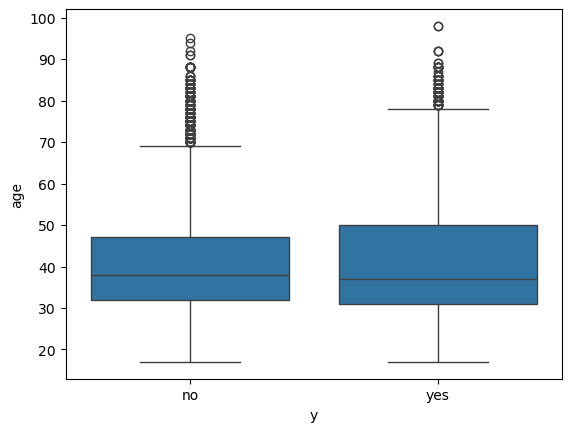

In [23]:
## Feature vs Target analysis
## numerical
sns.boxplot(x='y', y='age', data=df)

## categorical
pd.crosstab(df['job'], df['y'])

<Axes: >

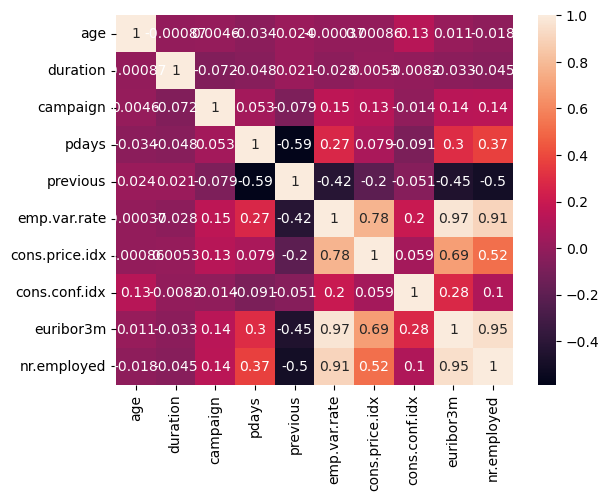

In [24]:
## correlation analysis
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

# Data Preprocessing

In [25]:
## convert target variables
df['y'] = df['y'].map({'no':0, 'yes':1})

In [26]:
## encode categorical variables
df= pd.get_dummies(df, drop_first=True)

# Training and prediction of model

In [27]:
X= df.drop(['y'], axis=True)
y= df['y']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [29]:
## Deploying models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [30]:
## creating a pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [31]:
## model dictionary
models = {
    "LogisticRegression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),

    "DecisionTree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost_SMOTE": Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('xgb', XGBClassifier(random_state=42))
    ])
}

for name, model in models.items():
    (model.fit(X_train, y_train))
    

## Evaluation metrics

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("confusion_matrix:", confusion_matrix(y_test, y_pred))


LogisticRegression
Accuracy: 0.8653799465889779
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238

confusion_matrix: [[6283 1027]
 [  82  846]]

DecisionTree
Accuracy: 0.8998543335761107
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      7310
           1       0.56      0.53      0.54       928

    accuracy                           0.90      8238
   macro avg       0.75      0.74      0.74      8238
weighted avg       0.90      0.90      0.90      8238

confusion_matrix: [[6923  387]
 [ 438  490]]

RandomForest
Accuracy: 0.915877640203933
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1 

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, 
    confusion_matrix
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Confusion_Matrix": confusion_matrix(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                Model  Accuracy  Precision    Recall        F1  \
0  LogisticRegression  0.865380   0.451682  0.911638  0.604070   
1        DecisionTree  0.899854   0.558723  0.528017  0.542936   
2        RandomForest  0.915878   0.691680  0.456897  0.550292   
3       XGBoost_SMOTE  0.920126   0.651685  0.625000  0.638064   

            Confusion_Matrix  
0  [[6283, 1027], [82, 846]]  
1  [[6923, 387], [438, 490]]  
2  [[7121, 189], [504, 424]]  
3  [[7000, 310], [348, 580]]  


## ROC_AUC SCORE

In [37]:
from sklearn.metrics import roc_auc_score

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,XGBoost_SMOTE,0.920126,0.651685,0.625000,0.638064,0.950887
2,RandomForest,0.915878,0.691680,0.456897,0.550292,0.948685
0,LogisticRegression,0.865380,0.451682,0.911638,0.604070,0.943811
1,DecisionTree,0.899854,0.558723,0.528017,0.542936,0.737538


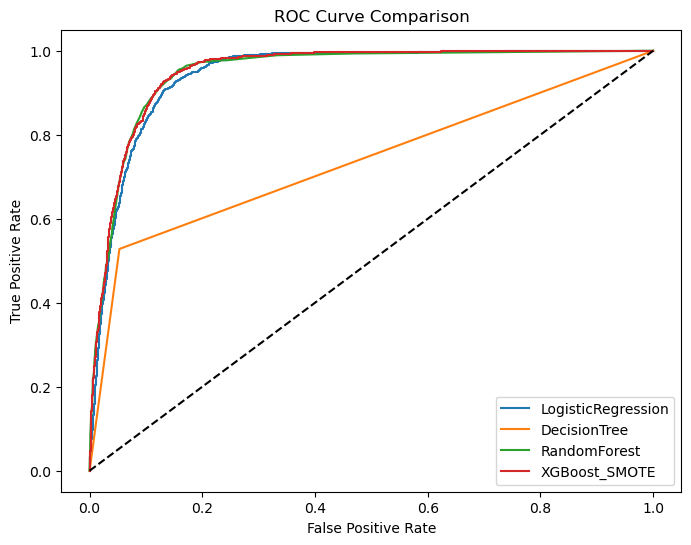

In [38]:
## ROC-AUC CURVE
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Cross Validation

In [39]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    )

    print(name)
    print("Mean ROC-AUC:", scores.mean())

LogisticRegression
Mean ROC-AUC: 0.9348869586495672
DecisionTree
Mean ROC-AUC: 0.7101822516719605
RandomForest
Mean ROC-AUC: 0.9392877797589716
XGBoost_SMOTE
Mean ROC-AUC: 0.942976016122631


In [40]:
## Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

## create a pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42))
])

In [41]:
## parameter grid
param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.8, 1.0]
}

In [42]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [3, 5, ...], 'xgb__n_estimators': [100, 200, ...], 'xgb__subsample': [0.8, 1.0]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [43]:
## evaluate tuned model
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

NameError: name 'best_model' is not defined

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

In [ ]:
## checking feature importance
import pandas as pd

importance = pd.Series(
    best_model.named_steps['xgb'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15).plot(
    kind='barh',
    figsize=(8,6)
)

In [ ]:
## error analysis
errors = pd.DataFrame(
    X_test[y_test != y_pred],
    columns=X.columns
)

errors.head()

In [ ]:
len(errors)

In [ ]:
errors.shape

In [ ]:
## error rate
error_rate = len(errors) / len(X_test)

print(f"Error Rate: {error_rate:.2%}")

In [ ]:
misclassified_mask = (y_test != y_pred)

error_df = pd.DataFrame(
    X_test[misclassified_mask],
    columns=X.columns
)

error_df["Actual"] = y_test.values[misclassified_mask]
error_df["Predicted"] = y_pred[misclassified_mask]

error_df.head()

In [ ]:
## save the model
import joblib

joblib.dump(
    best_model,
    "bank_marketing_model.pkl"
)

In [ ]:
type(X_test)